# Consumer Complaint Triage: Operational Risk Modeling

This notebook contains the complete workflow for processing, modeling, and evaluating retail banking complaints. It executes a full multi-model benchmark (Logistic Regression, LightGBM, DistilBERT, and Hybrid LightGBM) and dynamically generates presentation-ready visuals based on the live results.

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
# Standard Library
import re
import time

# Data Manipulation & Computation
import numpy as np
import pandas as pd
from scipy.sparse import hstack

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patheffects as pe

# Machine Learning (Scikit-Learn & LightGBM)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from lightgbm import LGBMClassifier

# Deep Learning (PyTorch & HuggingFace)
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

# =============================================================================
# GLOBAL CONFIGURATION & METRICS TRACKER
# =============================================================================

# Data Paths
CSV_PATH = '/content/drive/MyDrive/DataSciencePracticum_ConsumerComplaintResearch/data/complaints.csv'

# Scope Parameters
TARGET_PRODUCTS = ['Credit card', 'Credit card or prepaid card', 'Checking or savings account']
START_DATE = '2023-07-01'
END_DATE = '2026-06-30'
CHUNK_SIZE = 100000

# NLP Regex Patterns
P2P_PATTERN = r'venmo|paypal|zelle|cash app|peer-to-peer|p2p'
THEFT_PATTERN = r'identity theft|imposter|not mine|unauthorized card|stolen identification'

# Branding Palette for Executive Visuals
BG_COLOR = '#0f172a'
TEXT_COLOR = '#f8fafc'
ACCENT_COLOR = '#38bdf8'
MUTED_COLOR = '#475569'
HIGHLIGHT_COLOR = '#e11d48'

# Global Dictionary to store live metrics for visualizations
model_metrics = {}


## Step 1: Memory-Safe Data Ingestion
We ingest the data using chunks to prevent RAM overflow. The data is immediately filtered to our defined target products and temporal bounds.

In [36]:
dtype_spec = {'Product': 'category', 'Company response to consumer': 'category'}
chunk_list = []

try:
    for chunk in pd.read_csv(CSV_PATH, dtype=dtype_spec, low_memory=False, chunksize=CHUNK_SIZE):
        filtered_chunk = chunk[chunk['Product'].isin(TARGET_PRODUCTS) & chunk['Consumer complaint narrative'].notna()]
        chunk_list.append(filtered_chunk)

    df = pd.concat(chunk_list, ignore_index=True)
    df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')
    df = df[(df['Date received'] >= START_DATE) & (df['Date received'] <= END_DATE)]

    print("="*60)
    print(f"TEXT-PURE MODELING POOL ACTIVE")
    print(f"Total Text-Rich Rows: {len(df):,}")
    print("="*60)
except FileNotFoundError:
    print(f"[ERROR] File not found at {CSV_PATH}. Please check your path.")


TEXT-PURE MODELING POOL ACTIVE
Total Text-Rich Rows: 215,281


## Step 2: Target Engineering & Feature Extraction
We map the outcomes to a binary target (`1` for Relief, `0` for Explanation) and extract our 5 EDA-discovered structural features.

In [37]:
unresolved = ['In progress', 'Untimely response']
df = df[~df['Company response to consumer'].isin(unresolved)].copy()

relief_map = {
    'Closed with explanation': 0,
    'Closed with monetary relief': 1,
    'Closed with non-monetary relief': 1
}
df['Target_Remedy'] = df['Company response to consumer'].map(relief_map)

print("Extracting Structural and Behavioral Features...")
df['Character_Length'] = df['Consumer complaint narrative'].astype(str).str.len()
df['Word_Count'] = df['Consumer complaint narrative'].astype(str).str.split().str.len()
df['Privacy_Mask_Counts'] = df['Consumer complaint narrative'].astype(str).str.count('X{2,}')
df['P2P_Indicator'] = df['Consumer complaint narrative'].str.contains(P2P_PATTERN, case=False, regex=True).astype(int)
df['Theft_Indicator'] = df['Consumer complaint narrative'].str.contains(THEFT_PATTERN, case=False, regex=True).astype(int)

def clean_cfpb_narrative(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'XX/XX/XXXX', ' [REDACTED_DATE] ', text)
    text = re.sub(r'X{2,}', ' [REDACTED_PII] ', text)
    return re.sub(r'\s+', ' ', text.lower()).strip()

df['Clean_Narrative'] = df['Consumer complaint narrative'].apply(clean_cfpb_narrative)
print("Feature engineering complete.")


Extracting Structural and Behavioral Features...
Feature engineering complete.


## Step 3: Stratified Splitting & TF-IDF Baseline Models
We split the data, vectorize the text, and establish our initial baselines using Logistic Regression and a standard LightGBM configuration.

In [38]:
print("Partitioning Data and Training Baselines...")
df_train, df_test = train_test_split(df, test_size=0.20, random_state=42, stratify=df['Target_Remedy'])

vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), stop_words='english')
X_train_tfidf = vectorizer.fit_transform(df_train['Clean_Narrative'])
X_test_tfidf = vectorizer.transform(df_test['Clean_Narrative'])

# ==========================================
# MODEL 1: Logistic Regression
# ==========================================
t0 = time.time()
lr_model = LogisticRegression(max_iter=1000, n_jobs=-1, C=1.0)
lr_model.fit(X_train_tfidf, df_train['Target_Remedy'])
y_pred_lr = lr_model.predict(X_test_tfidf)
y_prob_lr = lr_model.predict_proba(X_test_tfidf)[:, 1]
time_lr = time.time() - t0
_, rec_lr, _, _ = precision_recall_fscore_support(df_test['Target_Remedy'], y_pred_lr, average='binary')
auc_lr = roc_auc_score(df_test['Target_Remedy'], y_prob_lr)

model_metrics['TF-IDF Logistic'] = {'recall': rec_lr, 'auc': auc_lr, 'time': time_lr}
print(f"Logistic Regression Complete (Recall: {rec_lr:.4f}, AUC: {auc_lr:.4f})")

# ==========================================
# MODEL 2: Base LightGBM
# ==========================================
t0 = time.time()
lgbm_base = LGBMClassifier(n_estimators=150, learning_rate=0.08, num_leaves=31, n_jobs=-1, random_state=42)
lgbm_base.fit(X_train_tfidf.astype(np.float32), df_train['Target_Remedy'])
y_pred_lgbm = lgbm_base.predict(X_test_tfidf.astype(np.float32))
y_prob_lgbm = lgbm_base.predict_proba(X_test_tfidf.astype(np.float32))[:, 1]
time_lgbm = time.time() - t0
_, rec_lgbm, _, _ = precision_recall_fscore_support(df_test['Target_Remedy'], y_pred_lgbm, average='binary')
auc_lgbm = roc_auc_score(df_test['Target_Remedy'], y_prob_lgbm)

model_metrics['TF-IDF LightGBM'] = {'recall': rec_lgbm, 'auc': auc_lgbm, 'time': time_lgbm}
print(f"Base LightGBM Complete (Recall: {rec_lgbm:.4f}, AUC: {auc_lgbm:.4f})")


Partitioning Data and Training Baselines...
Logistic Regression Complete (Recall: 0.2466, AUC: 0.7380)
[LightGBM] [Info] Number of positive: 43649, number of negative: 128425
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 13.652483 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2046371
[LightGBM] [Info] Number of data points in the train set: 172074, number of used features: 15000
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.253664 -> initscore=-1.079165
[LightGBM] [Info] Start training from score -1.079165


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Base LightGBM Complete (Recall: 0.2034, AUC: 0.7493)


## Step 4: Deep Learning Benchmark (DistilBERT)
To evaluate LLM performance, we fine-tune DistilBERT. To maintain reasonable execution times, we utilize a stratified 25k sample as established in the Week 4 analysis.

In [39]:
print("=== Running Model 3: DistilBERT Fine-Tuning (Weighted Loss) ===")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Training on {device} (Warning: Execution on full dataset may take an extended period).")

# Prepare full dataframes
train_sub = df_train.copy().rename(columns={'Target_Remedy': 'label', 'Clean_Narrative': 'text'})
test_sub = df_test.copy().rename(columns={'Target_Remedy': 'label', 'Clean_Narrative': 'text'})

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
def tokenize_fn(batch):
    return tokenizer(batch['text'], padding="max_length", truncation=True, max_length=128)

train_ds = Dataset.from_pandas(train_sub[['text', 'label']]).map(tokenize_fn, batched=True)
test_ds = Dataset.from_pandas(test_sub[['text', 'label']]).map(tokenize_fn, batched=True)

# 1. Calculate class weights based on the training data
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_sub['label']),
    y=train_sub['label']
)
class_weights_tensor = torch.tensor(class_weights_arr, dtype=torch.float32).to(device)

# 2. Create Custom Trainer to apply the weighted CrossEntropyLoss
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        # Apply the tensor weights to the loss function
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

bert_model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)
training_args = TrainingArguments(
    output_dir="./bert_results", num_train_epochs=1, per_device_train_batch_size=32,
    per_device_eval_batch_size=64, eval_strategy="no", save_strategy="no",
    fp16=(device == "cuda"), report_to="none"
)

# 3. Use the WeightedTrainer instead of the standard HuggingFace Trainer
trainer = WeightedTrainer(model=bert_model, args=training_args, train_dataset=train_ds)

t0 = time.time()
trainer.train()
test_preds = trainer.predict(test_ds)
time_bert = time.time() - t0

y_pred_bert = np.argmax(test_preds.predictions, axis=1)
y_prob_bert = torch.softmax(torch.tensor(test_preds.predictions), dim=1)[:, 1].numpy()

_, rec_bert, _, _ = precision_recall_fscore_support(test_sub['label'], y_pred_bert, average='binary', zero_division=0)
auc_bert = roc_auc_score(test_sub['label'], y_prob_bert)

# Save metrics globally to be picked up by the visualization cell
model_metrics['DistilBERT (LLM)'] = {'recall': rec_bert, 'auc': auc_bert, 'time': time_bert}
print(f"DistilBERT Complete (Recall: {rec_bert:.4f}, AUC: {auc_bert:.4f})")

=== Running Model 3: DistilBERT Fine-Tuning (Weighted Loss) ===
Training on cuda (Warning: Execution on full dataset may take an extended period).


Map:   0%|          | 0/172074 [00:00<?, ? examples/s]

Map:   0%|          | 0/43019 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.659066


Step,Training Loss
500,0.659066
1000,0.629973
1500,0.618254
2000,0.609158
2500,0.610435
3000,0.601428
3500,0.595263
4000,0.598251
4500,0.595696
5000,0.591228


DistilBERT Complete (Recall: 0.7107, AUC: 0.7404)


## Step 5: Proposed Architecture (EDA-Informed Hybrid LightGBM)
We horizontally stack the domain-specific EDA features onto the TF-IDF matrix to provide operational context, applying class weights to handle the imbalance.

In [40]:
print("=== Running Model 4: Proposed Hybrid LightGBM ===")
eda_features = ['Character_Length', 'Word_Count', 'Privacy_Mask_Counts', 'P2P_Indicator', 'Theft_Indicator']

X_train_hybrid = hstack([X_train_tfidf, df_train[eda_features].values]).tocsr()
X_test_hybrid = hstack([X_test_tfidf, df_test[eda_features].values]).tocsr()

t0 = time.time()
hybrid_model = LGBMClassifier(
    n_estimators=200, learning_rate=0.05, num_leaves=31,
    class_weight='balanced', n_jobs=-1, random_state=42
)
hybrid_model.fit(X_train_hybrid.astype(np.float32), df_train['Target_Remedy'])

y_pred_hyb = hybrid_model.predict(X_test_hybrid.astype(np.float32))
y_prob_hyb = hybrid_model.predict_proba(X_test_hybrid.astype(np.float32))[:, 1]
time_hyb = time.time() - t0

_, rec_hyb, _, _ = precision_recall_fscore_support(df_test['Target_Remedy'], y_pred_hyb, average='binary')
auc_hyb = roc_auc_score(df_test['Target_Remedy'], y_prob_hyb)

model_metrics['Hybrid LightGBM'] = {'recall': rec_hyb, 'auc': auc_hyb, 'time': time_hyb}
print(f"Hybrid Model Complete (Recall: {rec_hyb:.4f}, AUC: {auc_hyb:.4f})")


=== Running Model 4: Proposed Hybrid LightGBM ===
[LightGBM] [Info] Number of positive: 43649, number of negative: 128425
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 13.250120 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2047140
[LightGBM] [Info] Number of data points in the train set: 172074, number of used features: 15005
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Hybrid Model Complete (Recall: 0.6797, AUC: 0.7483)


## Step 6: Dynamic Threshold Calibration & Executive Artifact Generation
This block calculates the dynamic business optimum threshold, extracts live execution metrics from our `model_metrics` dictionary, and generates the 6 core presentation charts.

Generating Executive Presentation Charts from Live Data...
RAW DATA FOR PRESENTATION NOTES

--- 1 & 2. YEARLY TRENDS (VOLUME & RELIEF RATE) ---
 Year  Volume  Relief_Rate
 2023   26407     0.311395
 2024   64912     0.302070
 2025   92865     0.212071
 2026   30909     0.227636

--- 3. 2025 BANKING STRATEGIC DIVIDE (VOL > 5000) ---
Defensive Shielding (High Vol, Low Relief < 25%):
                           count      mean
Company                                   
JPMORGAN CHASE & CO.        8193  0.153790
NAVY FEDERAL CREDIT UNION   8731  0.076624
WELLS FARGO & COMPANY       5696  0.211201

Retention Strategy (High Vol, High Relief >= 25%):
                                       count      mean
Company                                               
BANK OF AMERICA, NATIONAL ASSOCIATION   5816  0.421596
CITIBANK, N.A.                          6613  0.492666

--- 4. RECALL COMPARISON DATA ---
DistilBERT (LLM): 71.07%
Hybrid LightGBM: 67.97%
TF-IDF Logistic: 24.66%
TF-IDF LightGBM: 20.3

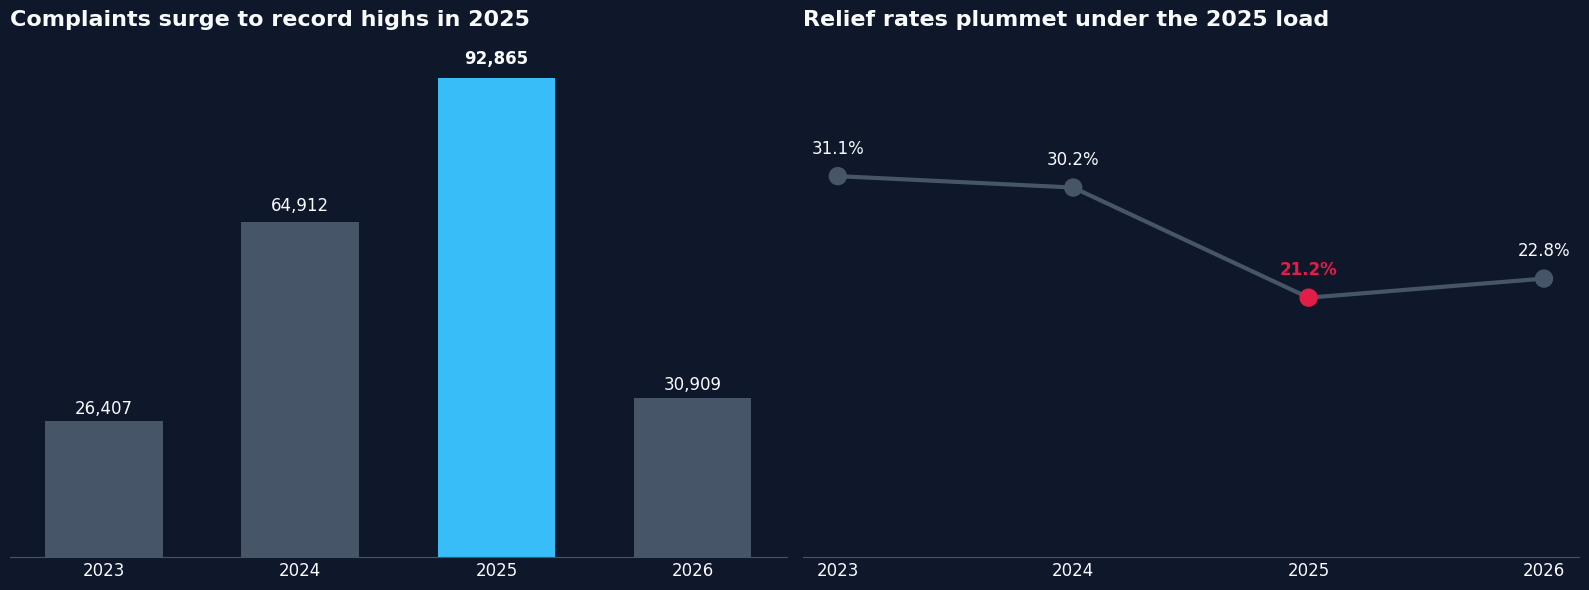

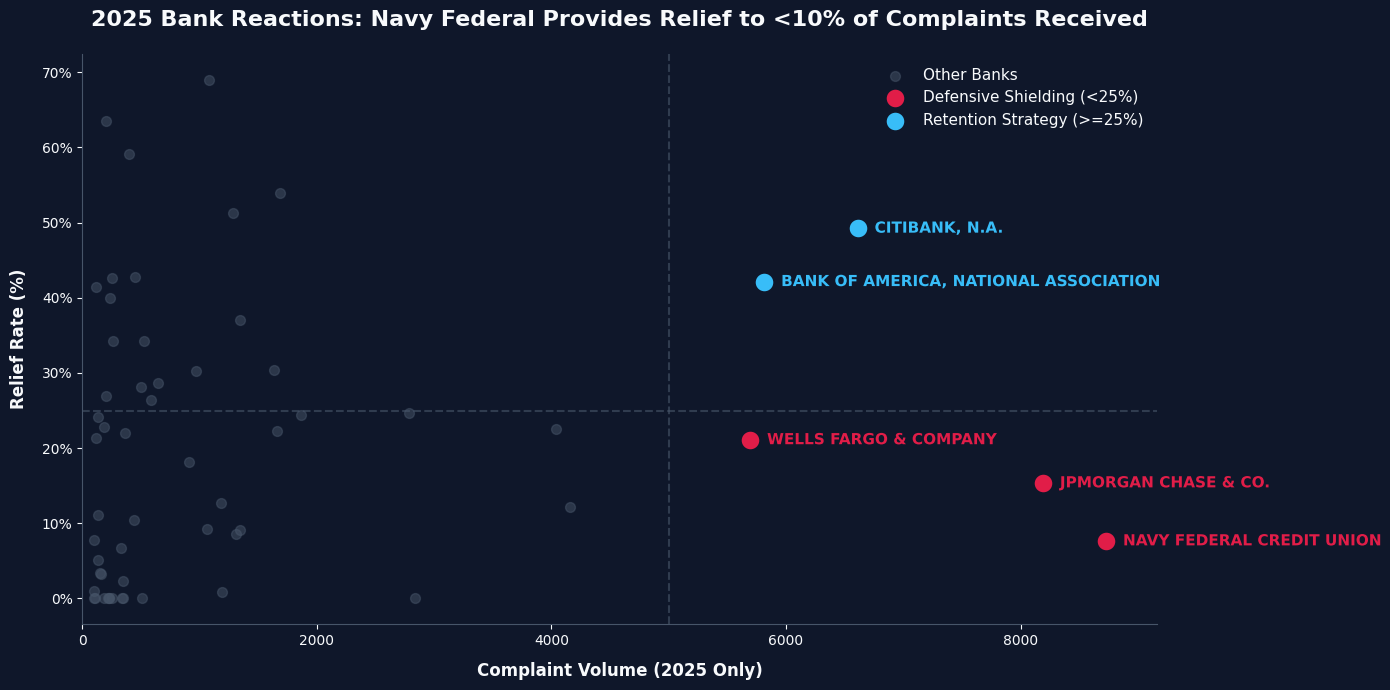

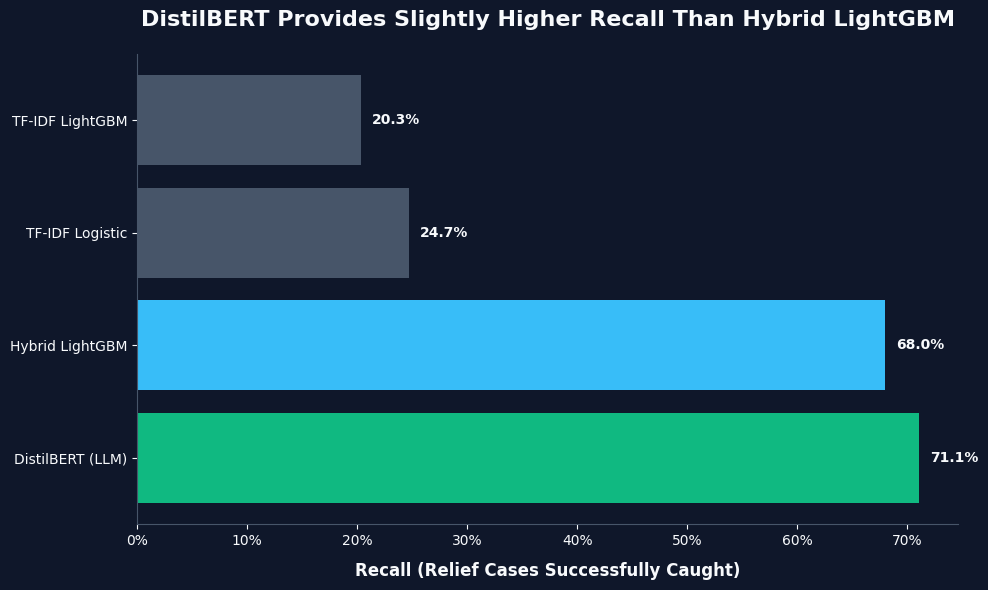

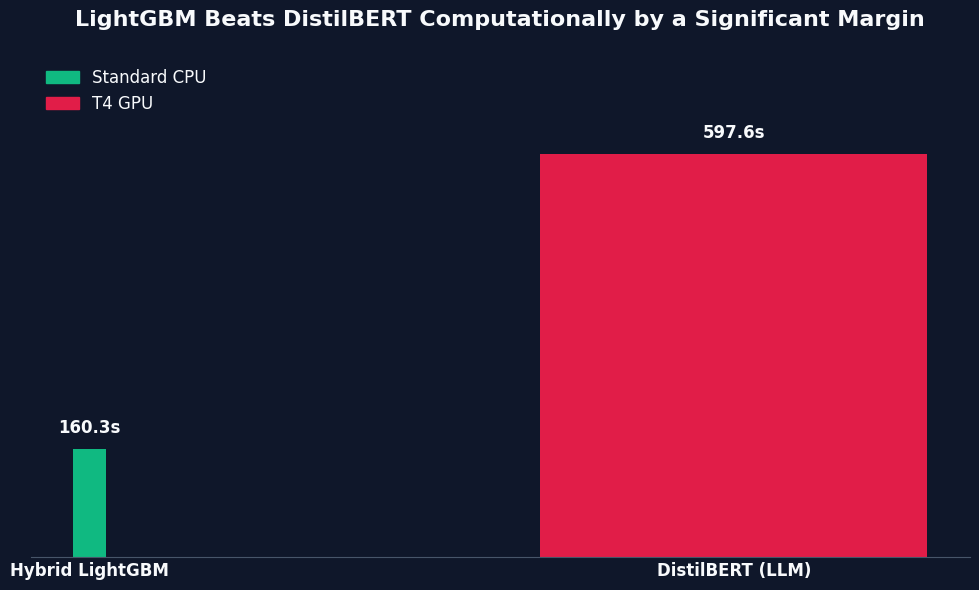

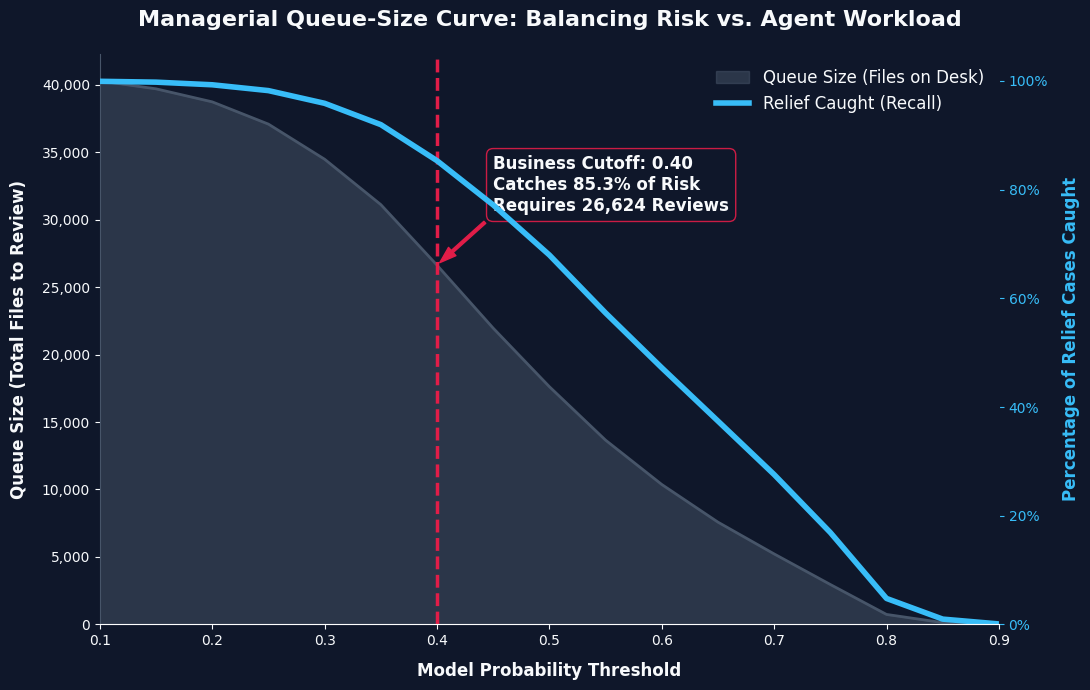


✅ SUCCESS: All presentation charts have been generated and displayed.


In [48]:
print("Generating Executive Presentation Charts from Live Data...")

from sklearn.metrics import roc_curve
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches

def configure_axis(ax, title, xlabel, ylabel):
    ax.set_facecolor(BG_COLOR)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(MUTED_COLOR)
    ax.spines['bottom'].set_color(MUTED_COLOR)
    ax.tick_params(colors=TEXT_COLOR)
    ax.set_title(title, color=TEXT_COLOR, fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel(xlabel, color=TEXT_COLOR, fontsize=12, fontweight='bold', labelpad=10)
    ax.set_ylabel(ylabel, color=TEXT_COLOR, fontsize=12, fontweight='bold', labelpad=10)

plt.style.use('dark_background')
SUCCESS_COLOR = '#10b981' # Emerald Green for targeted highlights

# =========================================================
# PHASE 1: COMPUTE AND PRINT ALL RAW TEXT DATA FIRST
# =========================================================

# 1. EDA Aggregations
df['Year'] = df['Date received'].dt.year

df['Length_Bucket'] = pd.cut(df['Word_Count'], bins=[0, 100, 250, np.inf], labels=['0-100', '101-250', '>250'])
df['Mask_Bucket'] = pd.cut(df['Privacy_Mask_Counts'], bins=[-1, 0, 1, 3, np.inf], labels=['Zero', 'One', '2-3', '4+'])

yearly_stats = df.groupby('Year').agg(
    Volume=('Target_Remedy', 'count'),
    Relief_Rate=('Target_Remedy', 'mean')
).reset_index()

len_stats = df.groupby('Length_Bucket', observed=True)['Target_Remedy'].mean().reset_index()
mask_stats = df.groupby('Mask_Bucket', observed=True)['Target_Remedy'].mean().reset_index()

df_2025 = df[df['Year'] == 2025]
bank_2025 = df_2025.groupby('Company')['Target_Remedy'].agg(['count', 'mean'])
bank_2025_all = bank_2025[bank_2025['count'] > 100].copy()
bank_2025_filtered = bank_2025[bank_2025['count'] > 5000].copy()
vol_thresh_2025 = 5000
relief_thresh_25 = 0.25

print("="*60)
print("RAW DATA FOR PRESENTATION NOTES")
print("="*60)

print("\n--- 1 & 2. YEARLY TRENDS (VOLUME & RELIEF RATE) ---")
print(yearly_stats.to_string(index=False))

print(f"\n--- 3. 2025 BANKING STRATEGIC DIVIDE (VOL > {vol_thresh_2025}) ---")
print("Defensive Shielding (High Vol, Low Relief < 25%):")
defensive_2025 = bank_2025_filtered[(bank_2025_filtered['count'] > vol_thresh_2025) & (bank_2025_filtered['mean'] < relief_thresh_25)]
print(defensive_2025)
print("\nRetention Strategy (High Vol, High Relief >= 25%):")
retention_2025 = bank_2025_filtered[(bank_2025_filtered['count'] > vol_thresh_2025) & (bank_2025_filtered['mean'] >= relief_thresh_25)]
print(retention_2025)

print("\n--- 4. RECALL COMPARISON DATA ---")
models = ['DistilBERT (LLM)', 'Hybrid LightGBM', 'TF-IDF Logistic', 'TF-IDF LightGBM']
recalls = [model_metrics.get(m, {}).get('recall', 0) * 100 for m in models]
for m, r in zip(models, recalls): print(f"{m}: {r:.2f}%")

print("\n--- 5. COMPUTE ROI DATA ---")
roi_models = ['Hybrid LightGBM', 'DistilBERT (LLM)']
compute_times = [model_metrics.get(m, {}).get('time', 0) for m in roi_models]
auc_scores = [model_metrics.get(m, {}).get('auc', 0) for m in roi_models]
for m, t, a in zip(roi_models, compute_times, auc_scores):
    print(f"{m} -> Time: {t:.2f}s | AUC: {a:.4f}")

print("\n--- 6. THRESHOLD CALIBRATION DATA (SET TO 0.40) ---")
thresholds = np.arange(0.10, 0.95, 0.05)
queue_volumes = []
recall_scores = []
actual_relief = df_test['Target_Remedy'].sum()

for thresh in thresholds:
    y_pred = (y_prob_hyb >= thresh).astype(int)
    tp = ((y_pred == 1) & (df_test['Target_Remedy'] == 1)).sum()
    queue_volumes.append(y_pred.sum())
    recall_scores.append(tp / actual_relief)

# Anchor business decision at 0.40
business_threshold = 0.40
idx_40 = np.where(np.isclose(thresholds, business_threshold))[0][0]
vol_at_40 = queue_volumes[idx_40]
rec_at_40 = recall_scores[idx_40]

print(f"Business Threshold: {business_threshold:.2f}")
print(f"Volume (Files to Review) at {business_threshold:.2f}: {vol_at_40:,}")
print(f"Recall (Risk Caught) at {business_threshold:.2f}: {rec_at_40:.2%}")

print("\n" + "="*60)
print("GENERATING VISUALIZATIONS...")
print("="*60 + "\n")

# =========================================================
# PHASE 2: GENERATE AND RENDER CHARTS
# =========================================================

# ---------------------------------------------------------
# Chart 1: fig1_macro_trends.png
# ---------------------------------------------------------
fig1, (ax_vol, ax_rel) = plt.subplots(1, 2, figsize=(16, 6))
fig1.patch.set_facecolor(BG_COLOR)

# Panel 1A: Volume
bar_colors_vol = [ACCENT_COLOR if y == 2025 else MUTED_COLOR for y in yearly_stats['Year']]
bars1 = ax_vol.bar(yearly_stats['Year'].astype(str), yearly_stats['Volume'], color=bar_colors_vol, width=0.6)

ax_vol.set_facecolor(BG_COLOR)
ax_vol.spines[['top', 'right', 'left']].set_visible(False)
ax_vol.spines['bottom'].set_color(MUTED_COLOR)
ax_vol.yaxis.set_visible(False)
ax_vol.tick_params(axis='x', length=0, labelsize=12, colors=TEXT_COLOR)

for i, bar in enumerate(bars1):
    height = bar.get_height()
    is_2025 = yearly_stats['Year'].iloc[i] == 2025
    font_w = 'bold' if is_2025 else 'normal'
    ax_vol.text(bar.get_x() + bar.get_width()/2., height + (height*0.02), f'{int(height):,}',
                ha='center', va='bottom', fontsize=12, fontweight=font_w, color=TEXT_COLOR)

ax_vol.set_title("Complaints surge to record highs in 2025",
                 fontsize=16, fontweight='bold', color=TEXT_COLOR, pad=20, loc='left')

# Panel 1B: Relief Rate
ax_rel.set_facecolor(BG_COLOR)
ax_rel.plot(yearly_stats['Year'].astype(str), yearly_stats['Relief_Rate'], color=MUTED_COLOR, linewidth=3, zorder=1)
scatter_colors = [HIGHLIGHT_COLOR if y == 2025 else MUTED_COLOR for y in yearly_stats['Year']]
ax_rel.scatter(yearly_stats['Year'].astype(str), yearly_stats['Relief_Rate'], color=scatter_colors, s=150, zorder=2)

ax_rel.spines[['top', 'right', 'left']].set_visible(False)
ax_rel.spines['bottom'].set_color(MUTED_COLOR)
ax_rel.yaxis.set_visible(False)
ax_rel.tick_params(axis='x', length=0, labelsize=12, colors=TEXT_COLOR)
ax_rel.set_ylim(bottom=0, top=yearly_stats['Relief_Rate'].max() + 0.1)

for i, row in yearly_stats.iterrows():
    is_crisis = row['Year'] == 2025
    text_color = HIGHLIGHT_COLOR if is_crisis else TEXT_COLOR
    font_w = 'bold' if is_crisis else 'normal'
    ax_rel.text(i, row['Relief_Rate'] + 0.015, f'{row["Relief_Rate"]:.1%}',
                ha='center', va='bottom', fontsize=12, fontweight=font_w, color=text_color)

ax_rel.set_title("Relief rates plummet under the 2025 load",
                 fontsize=16, fontweight='bold', color=TEXT_COLOR, pad=20, loc='left')

plt.tight_layout()
fig1.savefig("fig1_macro_trends.png", facecolor=BG_COLOR, dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# Chart 2: fig2_strategic_divide.png
# ---------------------------------------------------------
fig2, ax_scatter = plt.subplots(figsize=(14, 7))
fig2.patch.set_facecolor(BG_COLOR)
ax_scatter.set_facecolor(BG_COLOR)

ax_scatter.axvline(vol_thresh_2025, color=MUTED_COLOR, linestyle='--', linewidth=1.5, alpha=0.6)
ax_scatter.axhline(relief_thresh_25, color=MUTED_COLOR, linestyle='--', linewidth=1.5, alpha=0.6)

ax_scatter.scatter(bank_2025_all['count'], bank_2025_all['mean'], color=MUTED_COLOR, alpha=0.5, s=50, label="Other Banks")
ax_scatter.scatter(defensive_2025['count'], defensive_2025['mean'], color=HIGHLIGHT_COLOR, s=200, edgecolor=BG_COLOR, linewidth=1.5, label="Defensive Shielding (<25%)")
ax_scatter.scatter(retention_2025['count'], retention_2025['mean'], color=ACCENT_COLOR, s=200, edgecolor=BG_COLOR, linewidth=1.5, label="Retention Strategy (>=25%)")

for bank, row in pd.concat([defensive_2025, retention_2025]).iterrows():
    t_color = HIGHLIGHT_COLOR if row['mean'] < relief_thresh_25 else ACCENT_COLOR
    ax_scatter.annotate(bank, (row['count'], row['mean']), xytext=(12, 0), textcoords='offset points',
                        fontsize=11, fontweight='bold', color=t_color, va='center',
                        path_effects=[pe.withStroke(linewidth=4, foreground=BG_COLOR)])

configure_axis(ax_scatter, '2025 Bank Reactions: Navy Federal Provides Relief to <10% of Complaints Received', 'Complaint Volume (2025 Only)', 'Relief Rate (%)')
ax_scatter.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax_scatter.tick_params(colors=TEXT_COLOR)
ax_scatter.spines[['top', 'right']].set_visible(False)
ax_scatter.spines[['bottom', 'left']].set_color(MUTED_COLOR)
ax_scatter.grid(False)
ax_scatter.set_xlim(left=0)
ax_scatter.legend(frameon=False, loc='upper right', fontsize=11, labelcolor=TEXT_COLOR)

plt.tight_layout()
fig2.savefig("fig2_strategic_divide.png", facecolor=BG_COLOR, dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# Chart 3: chart1_recall_breakthrough.png
# ---------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(10, 6))
fig3.patch.set_facecolor(BG_COLOR)
ax3.set_facecolor(BG_COLOR)

# Make DistilBERT (index 0) Green
colors = [SUCCESS_COLOR, ACCENT_COLOR, MUTED_COLOR, MUTED_COLOR]
bars = ax3.barh(models, recalls, color=colors)

configure_axis(ax3, 'DistilBERT provides slightly higher recall than hybrid LightGBM', 'Recall (Relief Cases Successfully Caught)', '')
ax3.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=100))
ax3.tick_params(colors=TEXT_COLOR)
ax3.spines[['top', 'right']].set_visible(False)
ax3.spines[['bottom', 'left']].set_color(MUTED_COLOR)

for bar in bars:
    xval = bar.get_width()
    ax3.text(xval + 1, bar.get_y() + bar.get_height()/2, f'{xval:.1f}%', ha='left', va='center', color=TEXT_COLOR, fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_recall_breakthrough.png', facecolor=BG_COLOR, dpi=300)
plt.show()

# ---------------------------------------------------------
# Chart 4: chart2_operational_roi.png (Variable Width Compute Time)
# ---------------------------------------------------------
fig4, ax4 = plt.subplots(figsize=(10, 6))
fig4.patch.set_facecolor(BG_COLOR)
ax4.set_facecolor(BG_COLOR)

x = np.arange(len(roi_models))

# Map widths to High-RAM Compute Unit hourly burn rates
cu_rates = [0.14, 1.67]
max_time_width = 0.6
time_widths = [rate / max(cu_rates) * max_time_width for rate in cu_rates]

time_colors = [SUCCESS_COLOR, HIGHLIGHT_COLOR]
bars_time = ax4.bar(x, compute_times, width=time_widths, color=time_colors)

ax4.spines[['top', 'right', 'left']].set_visible(False)
ax4.spines['bottom'].set_color(MUTED_COLOR)
ax4.yaxis.set_visible(False)

ax4.set_xticks(x)
ax4.set_xticklabels(roi_models, color=TEXT_COLOR, fontsize=12, fontweight='bold')
ax4.tick_params(axis='x', length=0, colors=TEXT_COLOR)
ax4.set_title('LightGBM beats DistilBERT computationally by a significant margin', color=TEXT_COLOR, fontsize=16, fontweight='bold', pad=20)

if compute_times: ax4.set_ylim(0, max(compute_times) * 1.25)

for bar in bars_time:
    yval = bar.get_height()
    # Center text perfectly over variable widths
    ax4.text(bar.get_x() + bar.get_width()/2, yval + (max(compute_times)*0.03), f'{yval:.1f}s', ha='center', va='bottom', color=TEXT_COLOR, fontweight='bold', fontsize=12)

# Custom Legend for CPU/GPU mapping
cpu_patch = mpatches.Patch(color=SUCCESS_COLOR, label='Standard CPU')
gpu_patch = mpatches.Patch(color=HIGHLIGHT_COLOR, label='T4 GPU')
ax4.legend(handles=[cpu_patch, gpu_patch], loc='upper left', frameon=False, labelcolor=TEXT_COLOR, fontsize=12)

plt.tight_layout()
plt.savefig('chart2_operational_roi.png', facecolor=BG_COLOR, dpi=300)
plt.show()

# ---------------------------------------------------------
# Chart 5: fig3_queue_size_curve.png
# ---------------------------------------------------------
fig6, ax6 = plt.subplots(figsize=(11, 7))
fig6.patch.set_facecolor(BG_COLOR)
ax6.set_facecolor(BG_COLOR)
ax6.fill_between(thresholds, queue_volumes, color=MUTED_COLOR, alpha=0.5, label="Queue Size (Files on Desk)")
ax6.plot(thresholds, queue_volumes, color=MUTED_COLOR, linewidth=2)

ax6.set_title('Managerial Queue-Size Curve: Balancing Risk vs. Agent Workload', color=TEXT_COLOR, fontsize=16, fontweight='bold', pad=20)
ax6.set_xlabel('Model Probability Threshold', color=TEXT_COLOR, fontsize=12, fontweight='bold', labelpad=10)
ax6.set_ylabel('Queue Size (Total Files to Review)', color=TEXT_COLOR, fontsize=12, fontweight='bold', labelpad=10)
ax6.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax6.set_xlim([0.1, 0.9])
ax6.set_ylim(bottom=0)
ax6.tick_params(colors=TEXT_COLOR)
ax6.spines[['top', 'right']].set_visible(False)
ax6.spines[['bottom', 'left']].set_color(MUTED_COLOR)

ax6b = ax6.twinx()
ax6b.plot(thresholds, recall_scores, color=ACCENT_COLOR, linewidth=4, label="Relief Caught (Recall)")
ax6b.set_ylabel('Percentage of Relief Cases Caught', color=ACCENT_COLOR, fontsize=12, fontweight='bold', labelpad=10)
ax6b.tick_params(colors=ACCENT_COLOR)
ax6b.spines['top'].set_visible(False)
ax6b.spines['left'].set_visible(False)
ax6b.spines['right'].set_color(BG_COLOR)
ax6b.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax6b.set_ylim(0, 1.05)
ax6.axvline(business_threshold, color=HIGHLIGHT_COLOR, linestyle='--', linewidth=2.5, zorder=5)

annotation_text = f"Business Cutoff: {business_threshold:.2f}\nCatches {rec_at_40:.1%} of Risk\nRequires {vol_at_40:,} Reviews"
ax6.annotate(annotation_text, xy=(business_threshold, vol_at_40),
             xytext=(business_threshold + 0.05, vol_at_40 + (max(queue_volumes)*0.1)),
             arrowprops=dict(facecolor=HIGHLIGHT_COLOR, edgecolor=HIGHLIGHT_COLOR, shrink=0.05, width=2, headwidth=8),
             fontsize=12, fontweight='bold', color=TEXT_COLOR,
             bbox=dict(boxstyle="round,pad=0.4", fc=BG_COLOR, ec=HIGHLIGHT_COLOR, alpha=0.9))

lines_1, labels_1 = ax6.get_legend_handles_labels()
lines_2, labels_2 = ax6b.get_legend_handles_labels()
ax6.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right", frameon=False, labelcolor=TEXT_COLOR, fontsize=12)
plt.tight_layout()
plt.savefig('fig3_queue_size_curve.png', facecolor=BG_COLOR, dpi=300)
plt.show()

print("\n✅ SUCCESS: All presentation charts have been generated and displayed.")